# Exploratory Data Analysis (EDA)

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Load the ML Dataset

In [10]:
# Load the Barcelona noise ML dataset
dataset = pd.read_csv("data/bcn_noise_class_ml_dataset.csv")

print(f"Dataset shape: {dataset.shape}")
dataset.head()
print(dataset.columns.tolist())

Dataset shape: (12854, 22)
['road_id', 'noise_day', 'noise_evening', 'noise_night', 'road_category', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'betweenness', 'closeness_global', 'closeness_400', 'straightness', 'green', 'industrial', 'commercial']


## Reduce the number of columns

In [11]:
print(dataset.columns.tolist())

['road_id', 'noise_day', 'noise_evening', 'noise_night', 'road_category', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'betweenness', 'closeness_global', 'closeness_400', 'straightness', 'green', 'industrial', 'commercial']


<Axes: >

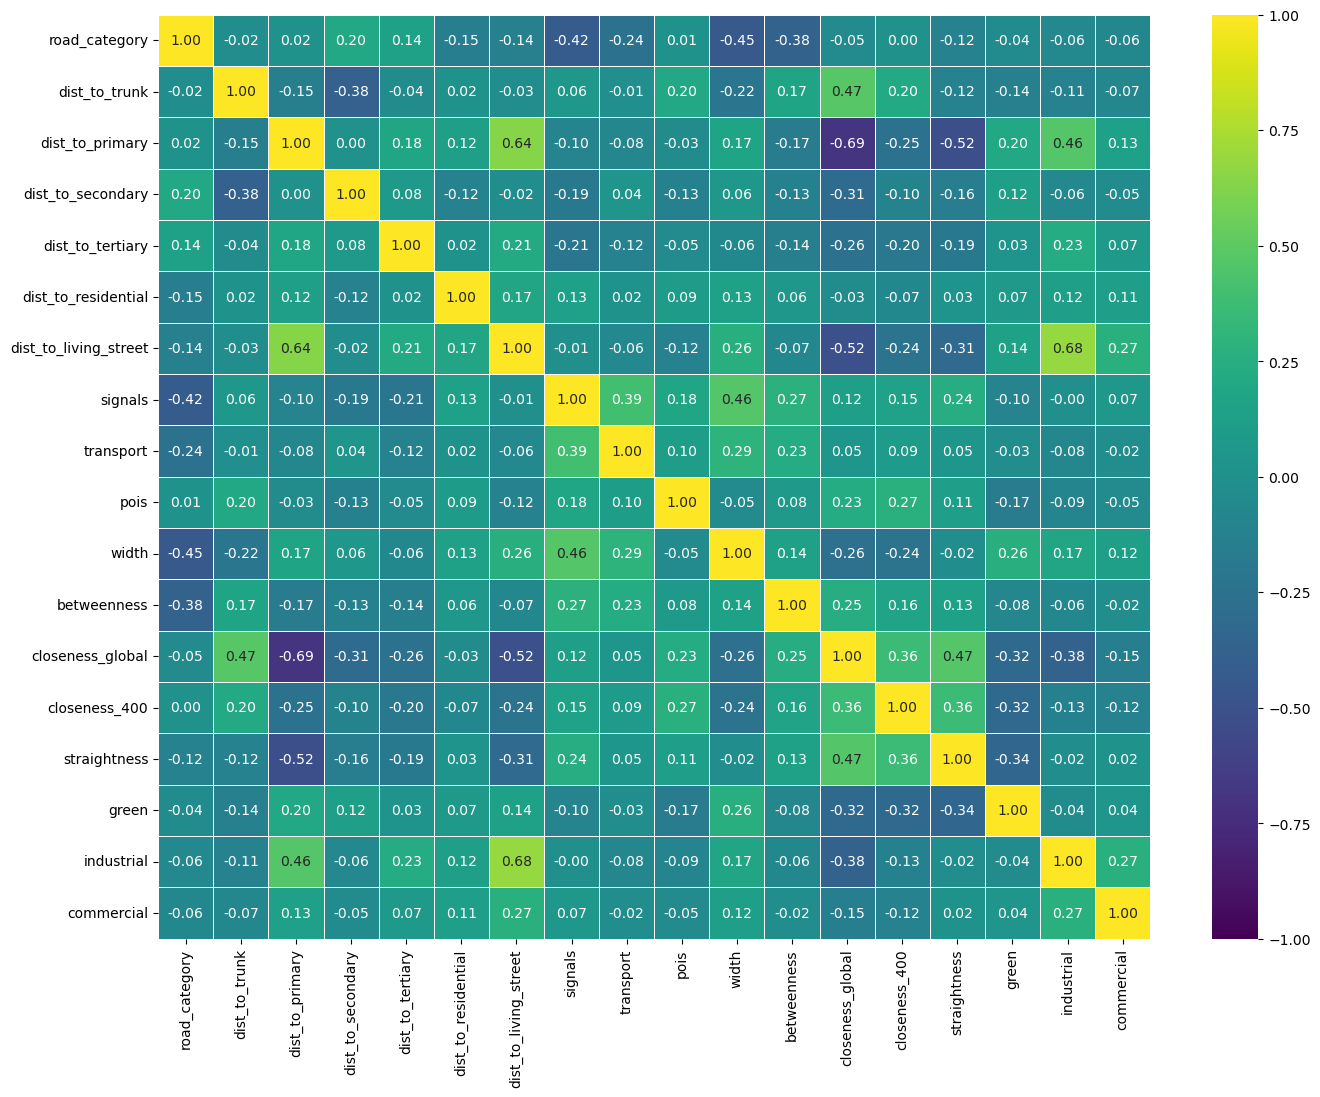

In [12]:
dataset_features = dataset.drop(columns=['road_id', 'noise_day', 'noise_evening', 'noise_night']) #dropping y and non-relevant columns
plt.figure(figsize=(16, 12))  # width, height in inches
sns.heatmap(dataset_features.corr(), center=0, linewidths=0.5,
                 cmap="viridis", vmin=-1, vmax=1, annot=True, fmt=".2f")

## Calculate Spearman correlation

Pearson measures linear relationships
-> very sensitive to outliers and nonlinear patterns

Spearman measures rank-order relationships
-> works well with nonlinear relationships and is more robust to outliers 

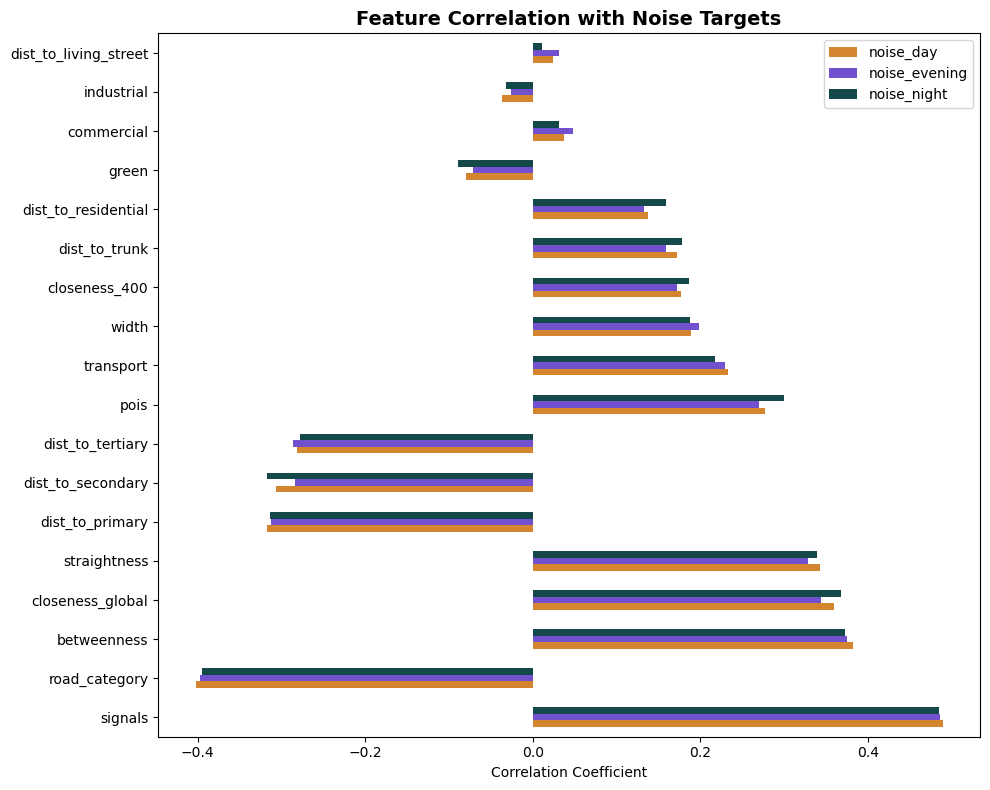

                       noise_day  noise_evening  noise_night
signals                 0.489133       0.486529     0.485293
betweenness             0.382086       0.375207     0.372998
closeness_global        0.359555       0.344057     0.368030
straightness            0.342335       0.328247     0.339445
pois                    0.277113       0.270547     0.299566
transport               0.233464       0.229181     0.217665
width                   0.188530       0.198624     0.187653
closeness_400           0.176361       0.172152     0.186891
dist_to_trunk           0.172231       0.158978     0.177744
dist_to_residential     0.137577       0.133198     0.159304
commercial              0.036694       0.047920     0.030717
dist_to_living_street   0.024223       0.031592     0.010911
industrial             -0.036492      -0.025938    -0.031572
green                  -0.079552      -0.071622    -0.088973
dist_to_tertiary       -0.281647      -0.285824    -0.277518
dist_to_secondary      -

In [13]:
# Extract correlations with noise predictions
dataset_filtered = dataset.drop(columns=['road_id']) #dropping non-relevant columns
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method = 'spearman')[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax,color=['#d58430', '#7251ce', '#144849'])
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

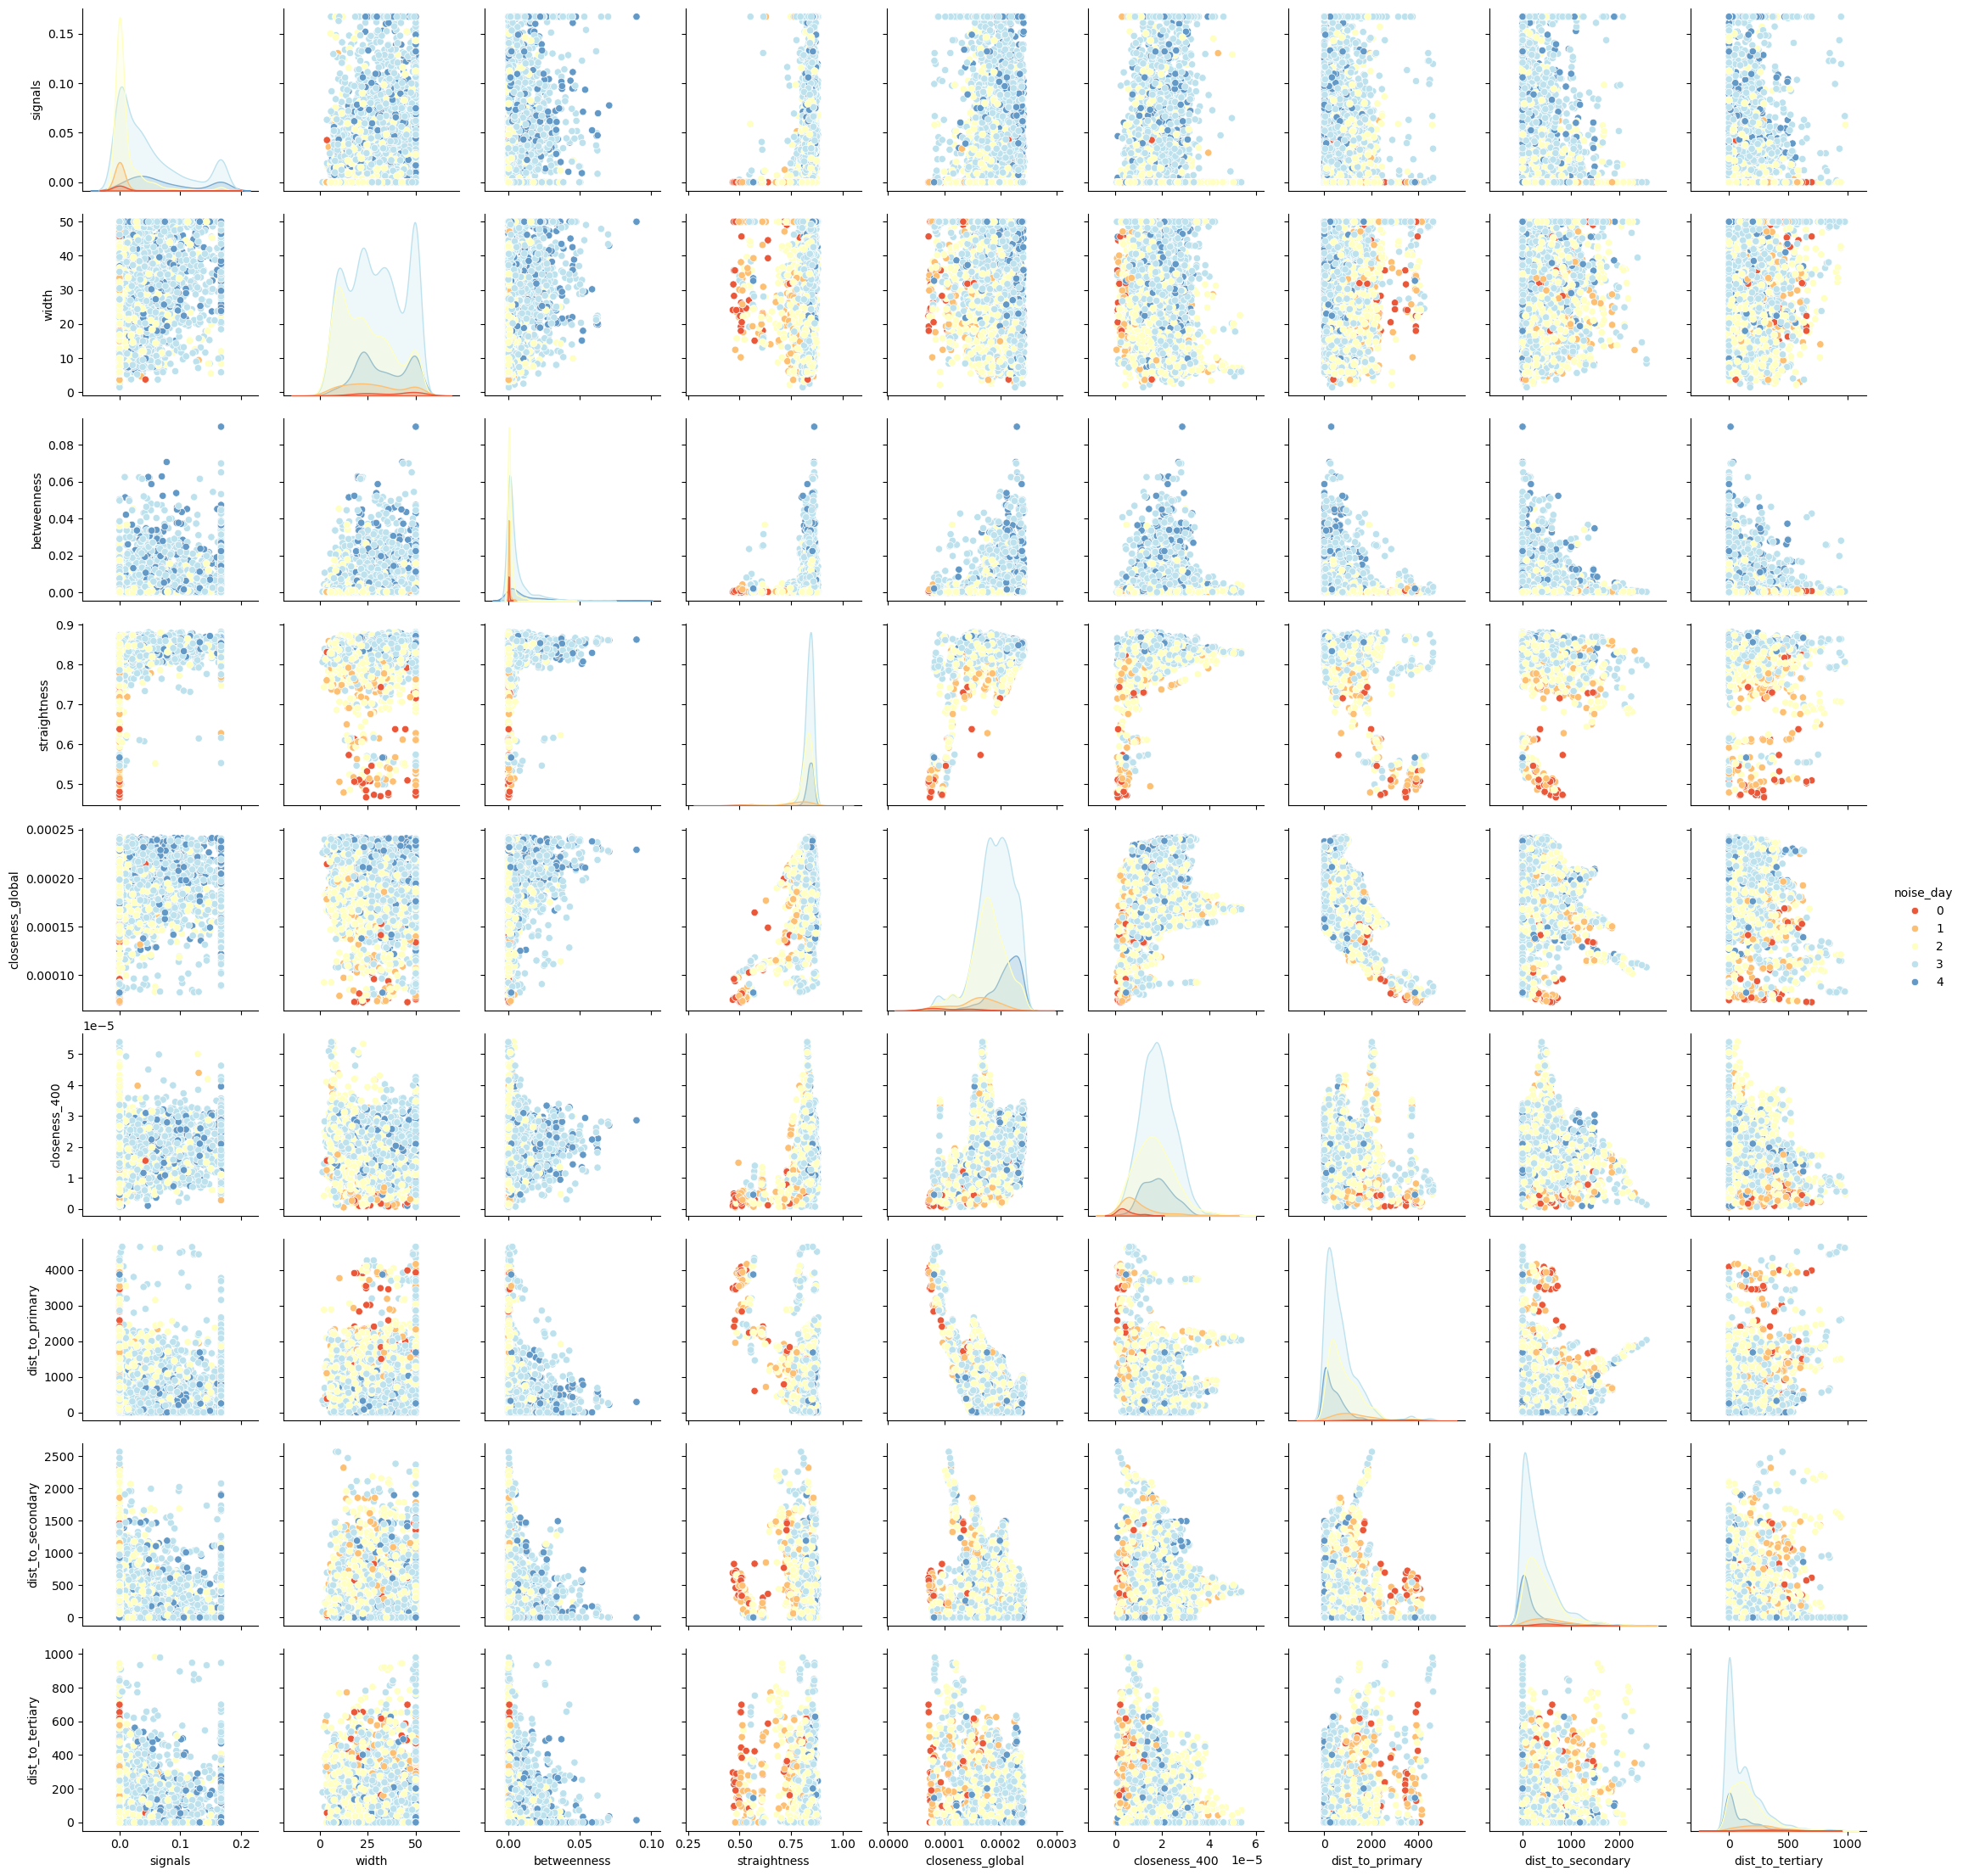

In [19]:
dataset_reduced = dataset[['noise_day','signals','width','betweenness','straightness','closeness_global','closeness_400','dist_to_primary','dist_to_secondary','dist_to_tertiary']]

# Sample randomly
sample = dataset_reduced.sample(n=5000, random_state=42).copy()

# Get unique noise_day values sorted and convert to ordered categorical
sorted_noise_values = sorted(sample['noise_day'].unique())
sample['noise_day'] = pd.Categorical(sample['noise_day'], categories=sorted_noise_values, ordered=True)

sns.pairplot(sample, hue="noise_day", palette="RdYlBu", corner=False)



In [15]:
# other plots can be
# histograms
# paralel coordinates plot
# boxplots/violonplots for distributions

In [16]:
print("Noise Day values:")
print(dataset['noise_day'].unique())
print("\nUnique values count:", dataset['noise_day'].nunique())


Noise Day values:
[2 3 1 4 0]

Unique values count: 5
